### 1. Infaltion Rates Clean up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_inflation = pd.read_csv('Inflation Rates.csv')

In [79]:
print(df_inflation.shape)
print(df_inflation.dtypes)
df_inflation.head()

(258, 4)
Year                          int64
Month                           str
Annual Average Inflation    float64
12-Month Inflation          float64
dtype: object


,Year,Month,Annual Average Inflation,12-Month Inflation
0,2026,May,4.66,6.68
1,2026,April,4.42,5.59
2,2026,March,4.29,4.39
3,2026,February,4.23,4.25
4,2026,January,4.16,4.40


In [ ]:
df_inflation = df_inflation.drop(columns=['Annual Average Inflation'])

df_inflation['date'] = pd.to_datetime(
    df_inflation['Year'].astype(str) + ' ' + df_inflation['Month'].astype(str) + ' 1',
    format='%Y %B %d'
)

df_inflation = df_inflation.drop(columns=['Year', 'Month'])

df_inflation = df_inflation.rename(columns={'12-Month Inflation': 'headline_inflation'})

df_inflation = df_inflation.sort_values('date').reset_index(drop=True)

df_inflation = df_inflation[df_inflation['date'] >= '2009-01-01'].reset_index(drop=True)

df_inflation = df_inflation[['date', 'headline_inflation']]

In [83]:

print(df_inflation.columns.tolist())
df_inflation.head()

['date', 'headline_inflation']


,date,headline_inflation
0,2009-01-01,13.22
1,2009-02-01,14.69
2,2009-03-01,14.60
3,2009-04-01,12.42
4,2009-05-01,9.61


In [84]:

print(df_inflation.shape)
print(df_inflation.isnull().sum())

(210, 2)
date                  0
headline_inflation    0
dtype: int64


### 2. Brent Crude Oil Clean Up

In [23]:
df_brent = pd.read_csv('Brent Crude Oil.csv')

In [27]:
print(df_brent.shape)
print(df_brent.dtypes)
print(df_brent.isnull().sum())
df_brent.head()

(10194, 2)
observation_date        str
DCOILBRENTEU        float64
dtype: object
observation_date      0
DCOILBRENTEU        282
dtype: int64


,observation_date,DCOILBRENTEU
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [ ]:
df_brent = df_brent.rename(columns={'observation_date': 'date', 'DCOILBRENTEU': 'brent_crude'})

df_brent['date'] = pd.to_datetime(df_brent['date'])

df_brent['brent_crude'] = df_brent['brent_crude'].interpolate(method='linear')

df_brent = df_brent[df_brent['date'] >= '2009-01-01'].reset_index(drop=True)

df_brent = df_brent.set_index('date')

df_brent = df_brent.resample('MS').mean().reset_index()

df_brent['brent_crude'] = df_brent['brent_crude'].round(2)

In [29]:
df_brent.head()

,date,brent_crude
0,2009-01-01,43.20
1,2009-02-01,43.23
2,2009-03-01,46.54
3,2009-04-01,50.24
4,2009-05-01,57.38


In [35]:
df_brent.tail()

,date,brent_crude
205,2026-02-01,70.89
206,2026-03-01,103.13
207,2026-04-01,118.71
208,2026-05-01,107.47
209,2026-06-01,95.27


In [30]:
print(df_brent.shape)
print(df_brent.dtypes)

(210, 2)
date           datetime64[us]
brent_crude           float64
dtype: object


In [31]:
print('Date range:', df_brent['date'].min(), 'to', df_brent['date'].max())

Date range: 2009-01-01 00:00:00 to 2026-06-01 00:00:00


In [32]:
print(df_brent.isnull().sum())

date           0
brent_crude    0
dtype: int64


### 3. CBK Rate Clean Up

In [34]:
df_cbk_rate = pd.read_csv('Central Bank Rate.csv')

In [ ]:
print(df_cbk_rate.shape)
print(df_cbk_rate.dtypes)
df_cbk_rate.head(10)

(122, 2)
Date        str
Rate    float64
dtype: object
Date    0
Rate    0
dtype: int64


,Date,Rate
0,06/08/2008,9.00
1,29/09/2008,9.00
2,01/10/2008,9.00
3,29/10/2008,9.00
4,01/12/2008,8.50
5,30/01/2009,8.50
6,20/03/2009,8.25
7,21/05/2009,8.00
8,22/07/2009,7.75
9,23/09/2009,7.75


In [37]:
print(df_cbk_rate.isnull().sum())

Date    0
Rate    0
dtype: int64


In [ ]:
df_cbk_rate = df_cbk_rate.rename(columns={'Date': 'date', 'Rate': 'cbk_rate'})

df_cbk_rate['date'] = pd.to_datetime(df_cbk_rate['date'], format='%d/%m/%Y')

df_cbk_rate = df_cbk_rate.sort_values('date').reset_index(drop=True)

df_cbk_rate = df_cbk_rate[df_cbk_rate['date'] >= '2009-01-01'].reset_index(drop=True)

monthly_index = pd.date_range(start='2009-01-01', end=df_cbk_rate['date'].max(), freq='MS')

df_monthly = pd.DataFrame({'date': monthly_index})

df_cbk_rate = pd.merge_asof(df_monthly, df_cbk_rate, on='date', direction='backward')

In [39]:
df_cbk_rate.head()

,date,cbk_rate
0,2009-01-01,NaN
1,2009-02-01,8.50
2,2009-03-01,8.50
3,2009-04-01,8.25
4,2009-05-01,8.25


In [40]:
df_cbk_rate.tail()

,date,cbk_rate
201,2025-10-01,9.50
202,2025-11-01,9.25
203,2025-12-01,9.25
204,2026-01-01,9.00
205,2026-02-01,9.00


In [41]:
print(df_cbk_rate.shape)
print(df_cbk_rate.dtypes)

(206, 2)
date        datetime64[us]
cbk_rate           float64
dtype: object


In [42]:
print('Date range:', df_cbk_rate['date'].min(), 'to', df_cbk_rate['date'].max())

Date range: 2009-01-01 00:00:00 to 2026-02-01 00:00:00


In [43]:
print(df_cbk_rate.isnull().sum())

date        0
cbk_rate    1
dtype: int64


In [44]:
#Fill the NaN with backward fill
df_cbk_rate['cbk_rate'] = df_cbk_rate['cbk_rate'].bfill()

In [45]:
df_cbk_rate.head()

,date,cbk_rate
0,2009-01-01,8.50
1,2009-02-01,8.50
2,2009-03-01,8.50
3,2009-04-01,8.25
4,2009-05-01,8.25


In [46]:
print(df_cbk_rate.isnull().sum())

date        0
cbk_rate    0
dtype: int64


In [47]:
print(df_cbk_rate.shape)

(206, 2)


### 4. KES/USD Exchange Rate Clean Up

In [48]:
df_exchange = pd.read_csv('Monthly Exchange rate.csv')

In [49]:
print(df_exchange.shape)
print(df_exchange.dtypes)
df_exchange.head()

(402, 31)
Unnamed: 0                                         str
Kenya Shilling Monthly Average Exchange Rates\1    str
Unnamed: 2                                         str
Unnamed: 3                                         str
Unnamed: 4                                         str
Unnamed: 5                                         str
Unnamed: 6                                         str
Unnamed: 7                                         str
Unnamed: 8                                         str
Unnamed: 9                                         str
Unnamed: 10                                        str
Unnamed: 11                                        str
Unnamed: 12                                        str
Unnamed: 13                                        str
Unnamed: 14                                        str
Unnamed: 15                                        str
Unnamed: 16                                        str
Unnamed: 17                                        str


,Unnamed: 0,Kenya Shilling Monthly Average Exchange Rates\1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,Year,Month,United States dollar,Sterling pound,Euro,South Africa Rand,Uganda shilling\2,Tanzania shilling\2,Rwanda Franc,Burundi Franc,...,Danish kroner,Austrian schilling,Finn marka,Spanish peseta,Indian rupee,Hong kong dollar,Singapore dollar,Saudi riyal,Chinese Yuan,Australian dollar
1,1993,1,36.23,55.62,NaN,NaN,NaN,NaN,NaN,NaN,...,5.74,3.19,6.71,31.64,1.4,NaN,NaN,NaN,NaN,NaN
2,1993,2,36.56,52.68,NaN,NaN,NaN,NaN,NaN,NaN,...,5.78,3.17,6.29,31.16,1.41,NaN,NaN,NaN,NaN,NaN
3,1993,3,43.12,62.92,NaN,NaN,NaN,NaN,NaN,NaN,...,6.78,3.72,7.21,36.62,1.44,NaN,NaN,NaN,NaN,NaN
4,1993,4,51.88,80.34,NaN,NaN,NaN,NaN,NaN,NaN,...,8.48,4.63,9.47,45.9,1.65,NaN,NaN,NaN,NaN,NaN


In [50]:
print(df_exchange.isnull().sum())

Unnamed: 0                                           0
Kenya Shilling Monthly Average Exchange Rates\1      0
Unnamed: 2                                           0
Unnamed: 3                                           0
Unnamed: 4                                          72
Unnamed: 5                                           9
Unnamed: 6                                          42
Unnamed: 7                                          42
Unnamed: 8                                         216
Unnamed: 9                                         216
Unnamed: 10                                         84
Unnamed: 11                                        290
Unnamed: 12                                          0
Unnamed: 13                                        291
Unnamed: 14                                          0
Unnamed: 15                                        290
Unnamed: 16                                        290
Unnamed: 17                                        290
Unnamed: 1

In [52]:
df_exchange = pd.read_csv('Monthly Exchange rate.csv', skiprows=1)

In [53]:

print(df_exchange.shape)
df_exchange.head()

(401, 31)


,Year,Month,United States dollar,Sterling pound,Euro,South Africa Rand,Uganda shilling\2,Tanzania shilling\2,Rwanda Franc,Burundi Franc,...,Danish kroner,Austrian schilling,Finn marka,Spanish peseta,Indian rupee,Hong kong dollar,Singapore dollar,Saudi riyal,Chinese Yuan,Australian dollar
0,1993,1,36.23,55.62,NaN,NaN,NaN,NaN,NaN,NaN,...,5.74,3.19,6.71,31.64,1.40,NaN,NaN,NaN,NaN,NaN
1,1993,2,36.56,52.68,NaN,NaN,NaN,NaN,NaN,NaN,...,5.78,3.17,6.29,31.16,1.41,NaN,NaN,NaN,NaN,NaN
2,1993,3,43.12,62.92,NaN,NaN,NaN,NaN,NaN,NaN,...,6.78,3.72,7.21,36.62,1.44,NaN,NaN,NaN,NaN,NaN
3,1993,4,51.88,80.34,NaN,NaN,NaN,NaN,NaN,NaN,...,8.48,4.63,9.47,45.90,1.65,NaN,NaN,NaN,NaN,NaN
4,1993,5,62.16,96.38,NaN,NaN,NaN,NaN,NaN,NaN,...,10.08,5.5,11.33,51.43,1.98,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_exchange = df_exchange[['Year', 'Month', 'United States dollar']]

df_exchange = df_exchange.rename(columns={'United States dollar': 'kes_usd'})

df_exchange['date'] = pd.to_datetime(df_exchange['Year'].astype(str) + '-' + df_exchange['Month'].astype(str) + '-01')

df_exchange = df_exchange.drop(columns=['Year', 'Month'])

df_exchange = df_exchange.sort_values('date').reset_index(drop=True)

df_exchange = df_exchange[df_exchange['date'] >= '2009-01-01'].reset_index(drop=True)

In [55]:
df_exchange.head()

,kes_usd,date
0,78.95,2009-01-01
1,79.53,2009-02-01
2,80.26,2009-03-01
3,79.63,2009-04-01
4,77.86,2009-05-01


In [56]:
print(df_exchange.shape)
print(df_exchange.dtypes)

(209, 2)
kes_usd           float64
date       datetime64[us]
dtype: object


In [57]:
print('Date range:', df_exchange['date'].min(), 'to', df_exchange['date'].max())

Date range: 2009-01-01 00:00:00 to 2026-05-01 00:00:00


In [58]:
print(df_exchange.isnull().sum())

kes_usd    0
date       0
dtype: int64


In [ ]:
#Exhange to reoder the columns
df_exchange = df_exchange[['date', 'kes_usd']]

In [60]:
df_exchange.head()

,date,kes_usd
0,2009-01-01,78.95
1,2009-02-01,79.53
2,2009-03-01,80.26
3,2009-04-01,79.63
4,2009-05-01,77.86


### 5. Money Supply(M3) & Forex Reserves (Depository Corporation Survey)

In [61]:
df_depository = pd.read_csv('Depository Corporation Survey Old.csv', 
                             header=None, encoding='latin1')

In [64]:
print(df_depository.shape)
df_depository.iloc[:30, :5]

(127, 365)


,0,1,2,3,4
0,DEPOSITORY CORPORATION SURVEY /1 (1996 -todate),NaN,NaN,NaN,NaN
1,(Ksh Millions),NaN,NaN,NaN,NaN
2,NaN,1995,1996,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,A S S E T S,Dec,Jan,Feb,Mar
5,NET FOREIGN ASSETS,"23,002","25,894","26,739","31,008"
6,1. Net foreign assets of CBK/GOK,"4,695","6,009","5,368","11,877"
7,2. Net foreign assets of Banks & NBFIs,"18,307","19,885","21,371","19,131"
8,NaN,NaN,NaN,NaN,NaN
9,DOMESTIC CREDIT,"248,733","251,370","252,371","252,411"


In [ ]:
years = df_depository.iloc[2, 1:].values
months = df_depository.iloc[4, 1:].values

m3_values = df_depository.iloc[23, 1:].values
forex_values = df_depository.iloc[6, 1:].values

df_monetary = pd.DataFrame({
    'year': years,
    'month': months,
    'm3': m3_values,
    'forex_reserves': forex_values
})

In [66]:
print(df_monetary.shape)
df_monetary.head(20)

(364, 4)


,year,month,m3,forex_reserves
0,1995,Dec,"244,755","4,695"
1,1996,Jan,"249,180","6,009"
2,NaN,Feb,"251,141","5,368"
3,NaN,Mar,"258,098","11,877"
4,NaN,Apr,"262,321","14,744"
5,NaN,May,"262,756","18,777"
6,NaN,Jun,"269,840","25,237"
7,NaN,Jul,"273,844","25,182"
8,NaN,Aug,"271,556","25,989"
9,NaN,Sep,"268,079","23,034"


In [ ]:
df_monetary['year'] = df_monetary['year'].ffill()

valid_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
                'January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
df_monetary = df_monetary[df_monetary['month'].isin(valid_months)].reset_index(drop=True)

df_monetary['date'] = pd.to_datetime(df_monetary['year'].astype(str) + ' ' + df_monetary['month'].astype(str) + ' 1', format='mixed')

df_monetary = df_monetary.drop(columns=['year', 'month'])

df_monetary = df_monetary[['date', 'm3', 'forex_reserves']]

df_monetary = df_monetary[df_monetary['date'] >= '2009-01-01'].reset_index(drop=True)

In [68]:
df_monetary.head()

,date,m3,forex_reserves
0,2009-01-01,"895,397","196,571"
1,2009-02-01,"900,031","195,113"
2,2009-03-01,"906,067","193,352"
3,2009-04-01,"928,824","191,659"
4,2009-05-01,"928,604","204,946"


In [70]:
df_monetary.tail()

,date,m3,forex_reserves
202,2025-11-01,5913633.99,898902.3803
203,2025-12-01,6029344.629,892546.5707
204,2026-01-01,6033698.724,893668.8865
205,2026-02-01,6133923.06,1176753.921
206,2026-03-01,6216589.735,1016371.659


In [71]:
print(df_monetary.shape)
print(df_monetary.dtypes)

(207, 3)
date              datetime64[us]
m3                           str
forex_reserves               str
dtype: object


In [72]:
print('Date range:', df_monetary['date'].min(), 'to', df_monetary['date'].max())

Date range: 2009-01-01 00:00:00 to 2026-03-01 00:00:00


In [73]:
print(df_monetary.isnull().sum())

date              0
m3                0
forex_reserves    0
dtype: int64


In [74]:
df_monetary['m3'] = df_monetary['m3'].astype(str).str.replace(',', '').astype(float)
df_monetary['forex_reserves'] = df_monetary['forex_reserves'].astype(str).str.replace(',', '').astype(float)

In [75]:
print(df_monetary.dtypes)
df_monetary.head()

date              datetime64[us]
m3                       float64
forex_reserves           float64
dtype: object


,date,m3,forex_reserves
0,2009-01-01,895397.0,196571.0
1,2009-02-01,900031.0,195113.0
2,2009-03-01,906067.0,193352.0
3,2009-04-01,928824.0,191659.0
4,2009-05-01,928604.0,204946.0


### 6. Cleaned and Combined Master Dataset

In [ ]:
#Merging
df = df_inflation \
    .merge(df_brent, on='date', how='inner') \
    .merge(df_cbk_rate, on='date', how='inner') \
    .merge(df_exchange, on='date', how='inner') \
    .merge(df_monetary, on='date', how='inner')

In [92]:
df.head()

,date,headline_inflation,brent_crude,cbk_rate,kes_usd,m3,forex_reserves
0,2009-01-01,13.22,43.20,8.50,78.95,895397.0,196571.0
1,2009-02-01,14.69,43.23,8.50,79.53,900031.0,195113.0
2,2009-03-01,14.60,46.54,8.50,80.26,906067.0,193352.0
3,2009-04-01,12.42,50.24,8.25,79.63,928824.0,191659.0
4,2009-05-01,9.61,57.38,8.25,77.86,928604.0,204946.0


In [10]:
df.tail()

,date,headline_inflation,brent_crude,cbk_rate,kes_usd,m3,forex_reserves
202,2025-10-01,4.56,64.54,9.50,129.24,5796361.951,8.699982e+05
203,2025-11-01,4.46,63.80,9.25,129.48,5913633.990,8.989024e+05
204,2025-12-01,4.49,62.62,9.25,129.13,6029344.629,8.925466e+05
205,2026-01-01,4.40,66.38,9.00,129.02,6033698.724,8.936689e+05
206,2026-02-01,4.25,70.89,9.00,129.02,6133923.060,1.176754e+06


In [9]:
df = df.drop(columns=['headline_inflation_diff'])

In [95]:
print(df.shape)
print(df.dtypes)

(207, 7)
date                  datetime64[us]
headline_inflation           float64
brent_crude                  float64
cbk_rate                     float64
kes_usd                      float64
m3                           float64
forex_reserves               float64
dtype: object


In [96]:
print('Date range:', df['date'].min(), 'to', df['date'].max())

Date range: 2009-01-01 00:00:00 to 2026-02-01 00:00:00


In [97]:
print(df.isnull().sum())

date                  0
headline_inflation    0
brent_crude           0
cbk_rate              0
kes_usd               0
m3                    0
forex_reserves        0
dtype: int64


The data is now fully cleaned and merged. I can now proceed to the other preprocesssing steps

In [3]:
df.to_csv('Cleaned Dataset.csv', index=False)

NameError: name 'df' is not defined

In [4]:
df = pd.read_csv("Cleaned Dataset.csv")
df.head()

,date,headline_inflation,brent_crude,cbk_rate,kes_usd,m3,forex_reserves
0,2009-01-01,13.22,43.20,8.50,78.95,895397.0,196571.0
1,2009-02-01,14.69,43.23,8.50,79.53,900031.0,195113.0
2,2009-03-01,14.60,46.54,8.50,80.26,906067.0,193352.0
3,2009-04-01,12.42,50.24,8.25,79.63,928824.0,191659.0
4,2009-05-01,9.61,57.38,8.25,77.86,928604.0,204946.0


## Exploratory Data Analysis

### 1. Decomposition

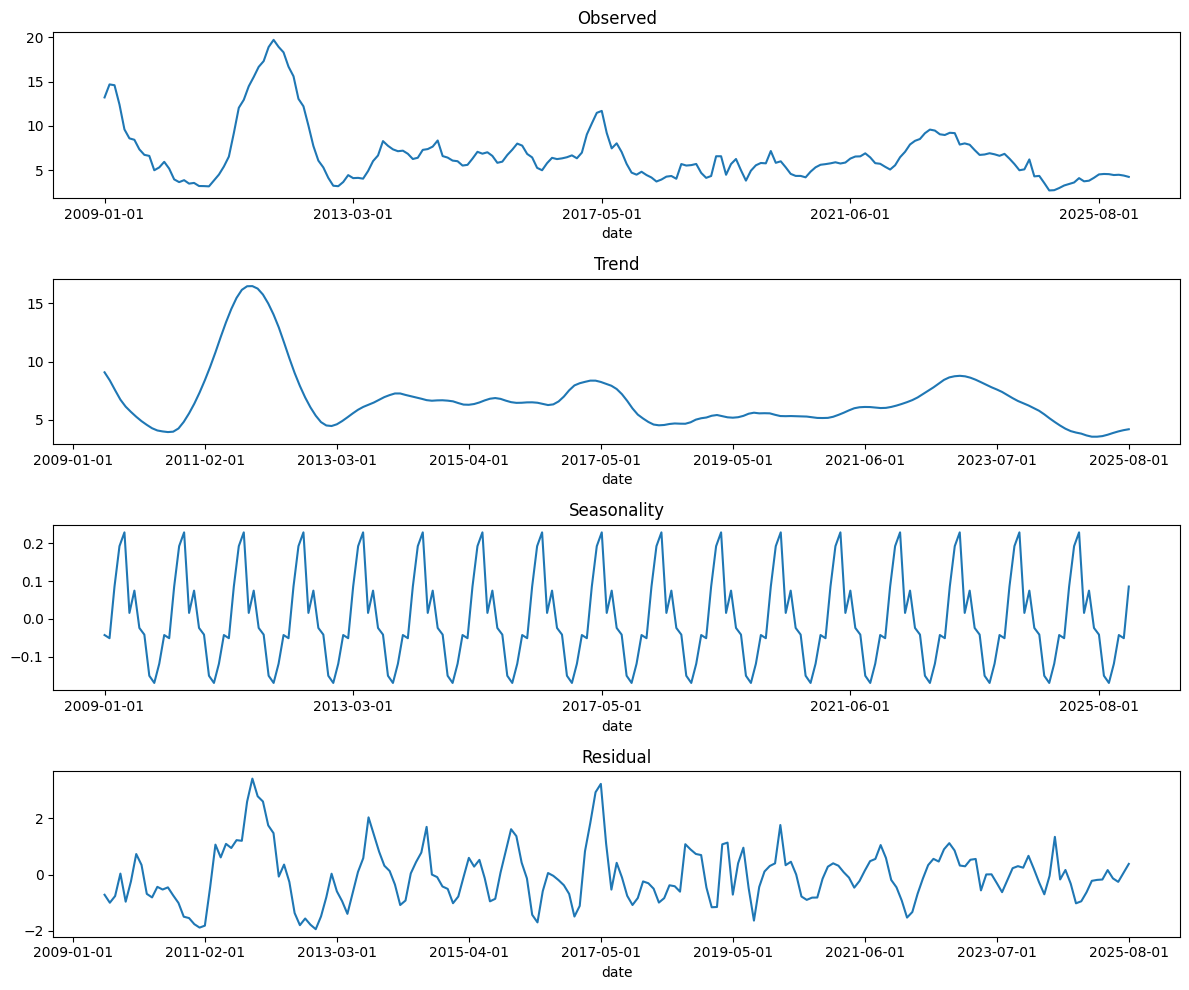

In [ ]:
df_decomp = df.set_index('date')

decomposition = seasonal_decompose(df_decomp['headline_inflation'], model='additive', period=12)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [ ]:
#ADF Test
result = adfuller(df['headline_inflation'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

if result[1] < 0.05:
    print('\nResult: Series is STATIONARY')
else:
    print('\nResult: Series is NON-STATIONARY — differencing required')

ADF Statistic: -2.8793058520558477
p-value: 0.04780790999129059
Critical Values:
   1%: -3.4645146202692527
   5%: -2.8765564361715534
   10%: -2.5747745328940375

Result: Series is STATIONARY


In [ ]:
#Didderencing
df['headline_inflation_diff'] = df['headline_inflation'].diff()

result_diff = adfuller(df['headline_inflation_diff'].dropna())

print('ADF Statistic (differenced):', result_diff[0])
print('p-value (differenced):', result_diff[1])

if result_diff[1] < 0.05:
    print('\nResult: Differenced series is STATIONARY')
else:
    print('\nResult: Still NON-STATIONARY')

ADF Statistic (differenced): -6.36155977543306
p-value (differenced): 2.4672469229396657e-08

Result: Differenced series is STATIONARY
